In [1]:
import os
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as pads
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
fc_colors = np.array(
    [
        [64, 80, 160],
        [64, 96, 176],
        [96, 192, 240],
        [144, 208, 224],
        [255, 255, 255],
        [240, 240, 96],
        [240, 208, 64],
        [224, 112, 64],
        [224, 64, 48],
    ],
    dtype=np.uint8,
)

FC_CMAP = LinearSegmentedColormap.from_list("fc", fc_colors / 255.0)

In [4]:
project_root = Path(os.environ["PROJECT_ROOT"])

analyze_test_profile_dir = project_root / "results/analyze_test_profile_pyspi"
analyze_test_profile_dir.mkdir(exist_ok=True)

In [5]:
spi_list_dir = project_root / "resources/spi_lists"
set_cache_dir(spi_list_dir)

spi_config_map, _ = load_spi_config_map()

In [6]:
all_spis = (spi_list_dir / "spi_list_all_284.txt").read_text().strip().split()
print("\n".join(all_spis[:10]))

cov_EmpiricalCovariance
cov_EllipticEnvelope
cov_GraphicalLasso
cov_GraphicalLassoCV
cov_LedoitWolf
cov_MinCovDet
cov_OAS
cov_ShrunkCovariance
cov-sq_EmpiricalCovariance
cov-sq_EllipticEnvelope


In [7]:
spi_id_map = {spi: idx for idx, spi in enumerate(all_spis)}

In [8]:
spi_table = pd.DataFrame.from_records(
    [
        {"spi_id": idx, "spi": spi, **spi_config_map[spi]}
        for idx, spi in enumerate(all_spis)
    ]
)
spi_table.head(4)

,spi_id,spi,module_name,fcn,params
0,0,cov_EmpiricalCovariance,.statistics.basic,Covariance,{'estimator': 'EmpiricalCovariance'}
1,1,cov_EllipticEnvelope,.statistics.basic,Covariance,{'estimator': 'EllipticEnvelope'}
2,2,cov_GraphicalLasso,.statistics.basic,Covariance,{'estimator': 'GraphicalLasso'}
3,3,cov_GraphicalLassoCV,.statistics.basic,Covariance,{'estimator': 'GraphicalLassoCV'}


In [9]:
(
    spi_table.groupby("module_name")
    .agg({"fcn": "nunique", "spi": "count"})
    .sort_values("spi", ascending=False)
)

,fcn,spi
module_name,,
.statistics.spectral,17,114
.statistics.infotheory,10,43
.statistics.basic,5,42
.statistics.distance,12,42
.statistics.misc,4,24
.statistics.causal,5,13
.statistics.wavelet,1,6


## Filtering SPIs

Here we load the test/profile results computed on one example run, varying the number of samples and features.

We filter the SPIs first by those that completed successfully. This excludes SPIs that timed out or raised errors.

We then filter by run time, applying a knee point cutoff to exclude outlier SPIs with very long run time.

In [10]:
test_profile_data_dir = project_root / "results/test_profile_pyspi"

df = pads.dataset(test_profile_data_dir, format="arrow").to_table().to_pandas()

spi_modules = [spi_config_map[spi]["module_name"] for spi in df["spi"]]
spi_funcs = [spi_config_map[spi]["fcn"] for spi in df["spi"]]

df.insert(2, "spi_func", spi_funcs)
df.insert(2, "spi_module", spi_modules)

print(df.shape)
print(df.dtypes)
df.iloc[:5, :9]

(1381, 11)
spi_id           int32
spi             object
spi_module      object
spi_func        object
n_samples        int32
n_features       int32
success           bool
run_time       float32
peak_mem_mb    float32
err             object
mat             object
dtype: object


,spi_id,spi,spi_module,spi_func,n_samples,n_features,success,run_time,peak_mem_mb
0,0,cov_EmpiricalCovariance,.statistics.basic,Covariance,50,100,True,0.499009,0.194725
1,0,cov_EmpiricalCovariance,.statistics.basic,Covariance,100,100,True,0.015255,0.220766
2,0,cov_EmpiricalCovariance,.statistics.basic,Covariance,200,100,True,0.019184,0.271357
3,0,cov_EmpiricalCovariance,.statistics.basic,Covariance,400,100,True,0.021997,0.387791
4,0,cov_EmpiricalCovariance,.statistics.basic,Covariance,400,200,True,0.149938,1.034933


In [11]:
# Check all SPIs have at least one record, i.e. no time outs on first trial (N=50, D=100)
print("All SPIs have at least one record:", df["spi"].nunique() == len(all_spis))

All SPIs have at least one record: True


In [12]:
spi_completion_counts = (
    df.query("n_samples >= 200")  # only look at trials with n_samples > n_features
    .groupby("spi")
    .agg({"spi": "count", "success": "sum"})
)

complete_spis = set(spi_completion_counts.query("success == 3").index)
complete_df = df.loc[df["spi"].isin(complete_spis)]

In [13]:
incomplete_spis = [spi for spi in all_spis if spi not in complete_spis]
incomplete_df = df.loc[df["spi"].isin(incomplete_spis)]

In [14]:
incomplete_spi_completion_counts = (
    incomplete_df.groupby(["spi", "spi_module"])
    .agg(
        {
            "spi": "count",
            "success": "sum",
            "n_samples": "max",
            "n_features": "max",
            "run_time": "max",
        }
    )
    .rename(columns={"spi": "count"})
    .sort_values(["count", "success"])
)

incomplete_spi_completion_counts

,,count,success,n_samples,n_features,run_time
spi,spi_module,,,,,
ccm_E-10_diff,.statistics.causal,2,1,100,100,4952.851562
ccm_E-10_max,.statistics.causal,2,1,100,100,4873.177246
ccm_E-10_mean,.statistics.causal,2,1,100,100,4863.850586
ccm_E-None_diff,.statistics.causal,2,1,100,100,5068.638672
ccm_E-None_max,.statistics.causal,2,1,100,100,5029.458496
ccm_E-None_mean,.statistics.causal,2,1,100,100,5059.985352
ccm_E-1_diff,.statistics.causal,2,2,100,100,4211.043457
ccm_E-1_max,.statistics.causal,2,2,100,100,4187.968750
ccm_E-1_mean,.statistics.causal,2,2,100,100,4365.957520


- First 20 SPIs timed out with 1 hour per trial time limit. This is far too long to spend computing one connectivity matrix...

- `GraphicalLasso` fails bc of bad default regularization strength. `GraphicalLassoCV` works fine though.

- `sgc` with order `None` fails with this error

  ```
  ValueError: Model estimation order did not converge at max_order = 50
  ```

  But variants of sgc with order not equal to None work fine.

- `xme_gaussian_k10` fails with following error (rank deficient)

  ```
  infodynamics.utils.NonPositiveDefiniteMatrixException: infodynamics.utils.NonPositiveDefiniteMatrixException: CholeskyDecomposition is only performed on positive-definite matrices. Some reasons for non-positive-definite matrix are listed at http://www2.gsu.edu/~mkteer/npdmatri.html - note: a correlation matrix is non-positive-definite if you have more variables than observations. Failed row is 7
  ```

  But it works for `xme_gaussian_k1`.

So, no unaccounted for failures.

Next we look at the run times at `n_samples=400`, `n_features=200`.

In [15]:
base_n_samples = 400
base_n_features = 200

run_time_df = complete_df.pivot(
    columns=["n_samples", "n_features"], index="spi", values="run_time"
)
mem_df = complete_df.pivot(
    columns=["n_samples", "n_features"], index="spi", values="peak_mem_mb"
)

run_time = run_time_df.loc[:, (base_n_samples, base_n_features)].values
mem = mem_df.loc[:, (base_n_samples, base_n_features)].values

In [16]:
# Find the "knee point" of sorted values, i.e. cutoff after which the values sharply increase.


def find_knee_point(values: np.ndarray, angle: float = 5 / 8 * np.pi) -> float:
    x = np.linspace(0, 1, len(values))
    y = (values - values.min()) / (values.max() - values.min())
    order = np.argsort(y)
    y = y[order]
    X = np.stack([x, y], axis=1)

    direction = np.array([np.cos(angle), np.sin(angle)])
    dot = X @ direction
    idx = np.argmin(dot)
    cutoff = values[order[idx]]
    return cutoff

In [17]:
# using an angle of 7 / 8 pi, to detect a sharp knee point
# a smaller angle, e.g. 5 / 8 pi would detect a more gradual knee point.
run_time_cutoff = find_knee_point(run_time, angle=7 / 8 * np.pi)
# round to nearest 5 minutes
run_time_cutoff = 5 * 60 * round(run_time_cutoff / 5 / 60)
include_spi_count = np.sum(run_time <= run_time_cutoff)
print(f"Cutoff: {run_time_cutoff:.0f}s, count: {include_spi_count}")

Cutoff: 1200s, count: 209


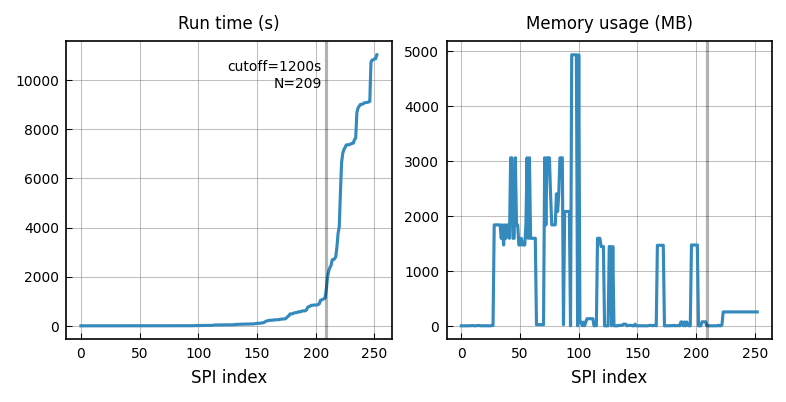

In [18]:
indices = np.argsort(run_time)

f, axs = plt.subplots(1, 2, figsize=(1.5 * PLOTW, 0.75 * PLOTW), layout="constrained")

plt.sca(axs[0])
plt.plot(run_time[indices])
plt.axvline(include_spi_count, color="k", alpha=0.3, label=f"cutoff={run_time_cutoff}s")
ymin, ymax = plt.ylim()
plt.text(
    include_spi_count - 4,
    0.98 * (ymin + ymax),
    (f"cutoff={run_time_cutoff}s\nN={include_spi_count}"),
    ha="right",
    va="top",
    fontsize="small",
)
# plt.legend()
plt.xlabel("SPI index")
plt.title("Run time (s)")

plt.sca(axs[1])
plt.plot(mem[indices])
plt.axvline(include_spi_count, color="k", alpha=0.3)
plt.xlabel("SPI index")
plt.title("Memory usage (MB)")

plt.savefig(analyze_test_profile_dir / f"pyspi_run_time_memory.{FORMAT}")

Estimate total run time for all SPIs and one run.

In [19]:
def estimate_total_run_time(n_samples: int, n_features: int):
    total_run_time = run_time[run_time <= run_time_cutoff].sum()

    # assume linear scaling in samples and quadratic in features
    # Nb, not strictly accurate, since some SPIs scale quadratically with sample length...
    total_run_time *= n_samples / base_n_samples
    total_run_time *= (n_features / base_n_features) ** 2
    return total_run_time

In [20]:
target_n_samples = 600
target_n_features = 200
total_run_time = estimate_total_run_time(target_n_samples, target_n_features)

print(
    f"Total run time (N={target_n_samples}, D={target_n_features}): "
    f"{total_run_time // 60:.0f} min"
)

Total run time (N=600, D=200): 786 min


Save list of selected SPIs

In [ ]:
include_spis_set = set(run_time_df.loc[run_time <= run_time_cutoff].index.values)

# Keep original order
include_spis = [spi for spi in all_spis if spi in include_spis_set]

with (
    spi_list_dir / f"spi_list_select_{run_time_cutoff}s_{include_spi_count}.txt"
).open("w") as file:
    print("\n".join(include_spis), file=file)

Make a formatted table of all included SPIs, grouped by category and function family.

In [22]:
include_spi_table = spi_table.copy()
include_spi_table["include"] = include_spi_table["spi"].isin(include_spis_set)

# Convert module name column to category
include_spi_table["module_name"] = [
    name.split(".")[-1].capitalize() for name in include_spi_table["module_name"]
]
include_spi_table = include_spi_table.rename(
    columns={"module_name": "category", "fcn": "function"}
)

In [23]:
include_spi_table.head(4)

,spi_id,spi,category,function,params,include
0,0,cov_EmpiricalCovariance,Basic,Covariance,{'estimator': 'EmpiricalCovariance'},True
1,1,cov_EllipticEnvelope,Basic,Covariance,{'estimator': 'EllipticEnvelope'},True
2,2,cov_GraphicalLasso,Basic,Covariance,{'estimator': 'GraphicalLasso'},False
3,3,cov_GraphicalLassoCV,Basic,Covariance,{'estimator': 'GraphicalLassoCV'},True


In [24]:
include_category_spi_counts = (
    include_spi_table.groupby("category")
    .agg({"spi": "count", "include": "sum"})
    .rename(columns={"spi": "total"})
)

include_category_spi_counts

,total,include
category,,
Basic,42,38
Causal,13,2
Distance,42,33
Infotheory,43,30
Misc,24,22
Spectral,114,78
Wavelet,6,6


In [25]:
include_category_func_counts_total = (
    include_spi_table.groupby("category")
    .agg({"function": "nunique"})
    .rename(columns={"function": "total"})
)

include_category_func_counts_include = (
    include_spi_table.query("include")
    .groupby("category")
    .agg({"function": "nunique"})
    .rename(columns={"function": "include"})
)

include_category_func_counts = pd.concat(
    [include_category_func_counts_total, include_category_func_counts_include],
    axis=1,
)

include_category_func_counts

,total,include
category,,
Basic,5,5
Causal,5,2
Distance,12,9
Infotheory,10,8
Misc,4,3
Spectral,17,12
Wavelet,1,1


In [26]:
include_category_func_spis_counts = (
    include_spi_table.groupby(["category", "function"], sort=False)
    .agg({"spi_id": "count", "include": "sum", "spi": list})
    .rename(columns={"spi_id": "total"})
)

include_category_func_spis_counts.head(4)

total  include  \
category function                     
Basic    Covariance     16       14   
         Precision      16       14   
         SpearmanR       2        2   
         KendallTau      2        2   

                                                                   spi  
category function                                                       
Basic    Covariance  [cov_EmpiricalCovariance, cov_EllipticEnvelope...  
         Precision   [prec_EmpiricalCovariance, prec_EllipticEnvelo...  
         SpearmanR                           [spearmanr-sq, spearmanr]  
         KendallTau                        [kendalltau-sq, kendalltau]

In [27]:
# Get short identifier names for each function
def get_short_func_name(spi: str):
    return re.split(r"[_-]", spi)[0]


short_func_name_map = defaultdict(set)

for _, row in spi_table.iterrows():
    func = row["fcn"]
    spi = row["spi"]
    short_func_name_map[func].add(get_short_func_name(spi))

# Nb, all SPI funcs have a unique identifier except transfer entropy, which weirdly uses
# 'gc' for some.
# https://github.com/DynamicsAndNeuralSystems/pyspi/blob/v1.1.1/pyspi/statistics/infotheory.py#L356
short_func_name_map = {k: v.pop() for k, v in short_func_name_map.items()}

In [28]:
# Each spi on a new line, included shown in bold
def format_spis(spis: list[str]):
    spis_fmt = []
    for spi in spis:
        spi_fmt = f"({spi_id_map[spi] + 1:03d}) {spi}"
        if spi in include_spis_set:
            spi_fmt = f"<b>{spi_fmt}</b>"
        spis_fmt.append(spi_fmt)
    return "<br>".join(spis_fmt)


# Add counts and short identifier names
def format_index(idx: tuple[str, str]):
    category, func = idx
    short_func = short_func_name_map[func]

    cat_spi_total, cat_spi_include = include_category_spi_counts.loc[
        category, ["total", "include"]
    ]
    cat_func_total, cat_func_include = include_category_func_counts.loc[
        category, ["total", "include"]
    ]
    func_spi_total, func_spi_include = include_category_func_spis_counts.loc[
        (category, func), ["total", "include"]
    ]

    category_fmt = (
        f"{category}<br>"
        f"({cat_func_include}/{cat_func_total} functions)<br>"
        f"({cat_spi_include}/{cat_spi_total} SPIs)"
    )

    func_fmt = f"{func} ({short_func})<br>({func_spi_include}/{func_spi_total} SPIs)"
    return category_fmt, func_fmt


include_spi_table_fmt = include_category_func_spis_counts.copy()
include_spi_table_fmt = include_spi_table_fmt.drop(columns=["total", "include"])
include_spi_table_fmt["spi"] = include_spi_table_fmt["spi"].map(format_spis)
include_spi_table_fmt.index = include_spi_table_fmt.index.map(format_index)
include_spi_table_fmt.index.names = ["Category", "Function"]
include_spi_table_fmt.columns = ["SPIs"]

In [29]:
include_spi_table_fmt_style = include_spi_table_fmt.style.set_properties(
    **{"text-align": "left"}
).set_table_styles(
    [
        {"selector": "th", "props": [("text-align", "center")]},
        {
            "selector": ".row_heading",
            "props": [("text-align", "center"), ("vertical-align", "top")],
        },
    ]
)

include_spi_table_fmt_style

In [30]:
include_spi_table_fmt_style.to_html(analyze_test_profile_dir / "include_spi_table.html")

### Visualize example matrices for selected SPIs

In [31]:
def matshow(
    mat: np.ndarray,
    vmin: float | None = None,
    vmax: float | None = None,
    **kwargs,
):
    if vmax is None:
        vmax = np.max(np.abs(mat))
    if vmin is None:
        vmin = -vmax

    kwargs = {
        "cmap": FC_CMAP,
        "interpolation": "none",
        **kwargs,
    }
    plt.imshow(mat, vmin=vmin, vmax=vmax, **kwargs)
    plt.xticks([])
    plt.yticks([])

In [32]:
mat_df = (
    df.loc[df["spi"].isin(include_spis_set)]
    .query(f"n_samples == {base_n_samples} and n_features == {base_n_features}")
    .reset_index(drop=True)
)

mat_df.insert(2, "category", [module.split(".")[-1] for module in mat_df["spi_module"]])
mat_df.insert(3, "identifier", [spi.split("_")[0] for spi in mat_df["spi"]])

print(mat_df.shape)
mat_df.iloc[:4, :10]

(209, 13)


,spi_id,spi,category,identifier,spi_module,spi_func,n_samples,n_features,success,run_time
0,0,cov_EmpiricalCovariance,basic,cov,.statistics.basic,Covariance,400,200,True,0.149938
1,1,cov_EllipticEnvelope,basic,cov,.statistics.basic,Covariance,400,200,True,2.553292
2,3,cov_GraphicalLassoCV,basic,cov,.statistics.basic,Covariance,400,200,True,86.003288
3,4,cov_LedoitWolf,basic,cov,.statistics.basic,Covariance,400,200,True,0.025151


In [33]:
# mapping of (category, identifier) -> row indices
row_lut = defaultdict(list)

for idx, row in mat_df.iterrows():
    row_lut[(row["category"], row["identifier"])].append(idx)

In [34]:
nrow = len(row_lut)
ncol = max(len(v) for v in row_lut.values())
print(nrow, ncol)

47 18


SPIs organized with each function on another row.

In [35]:
def plot_example_matrices_by_func(category: str | None = None):
    if category is not None:
        cat_row_lut = {
            (cat, id): indices
            for (cat, id), indices in row_lut.items()
            if cat == category.lower()
        }
    else:
        cat_row_lut = row_lut

    plotw = 1.5
    ploth = 0.85 * plotw

    # wrap functions with lots of SPIs to max 7 cols
    ncol = 7
    wrap_cat_row_lut = {}
    for (cat, id), indices in cat_row_lut.items():
        for row_ind in range(int(np.ceil(len(indices) / ncol))):
            wrap_cat_row_lut[(cat, id, row_ind)] = indices[
                row_ind * ncol : (row_ind + 1) * ncol
            ]

    nrow = len(wrap_cat_row_lut)

    f, axs = plt.subplots(
        nrow,
        ncol,
        figsize=(ncol * plotw, nrow * ploth),
        layout="constrained",
        squeeze=False,
    )

    for ii, (cat, id, row_ind) in enumerate(wrap_cat_row_lut):
        if ii >= nrow:
            break

        indices = wrap_cat_row_lut[(cat, id, row_ind)]
        for jj in range(ncol):
            plt.sca(axs[ii, jj])
            if jj >= len(indices):
                plt.axis("off")
                continue

            idx = indices[jj]
            spi = mat_df.loc[idx, "spi"]
            mat = mat_df.loc[idx, "mat"]
            mat = mat.reshape(base_n_features, base_n_features)

            vmax = max(np.nanquantile(np.abs(mat), 0.95), 1e-8)
            matshow(mat, vmax=vmax)
            cbar = plt.colorbar(fraction=0.05, pad=0.05)
            cbar.ax.tick_params(labelsize="xx-small")

            title = f"({spi_id_map[spi] + 1:03d}) {spi}"
            plt.title(title[:26], fontsize="x-small", pad=4)
            if jj == 0:
                ylabel = f"{cat} - {id}"
                if row_ind > 0:
                    ylabel = f"{ylabel} (cont)"
                plt.ylabel(ylabel, fontsize="small")

    return f

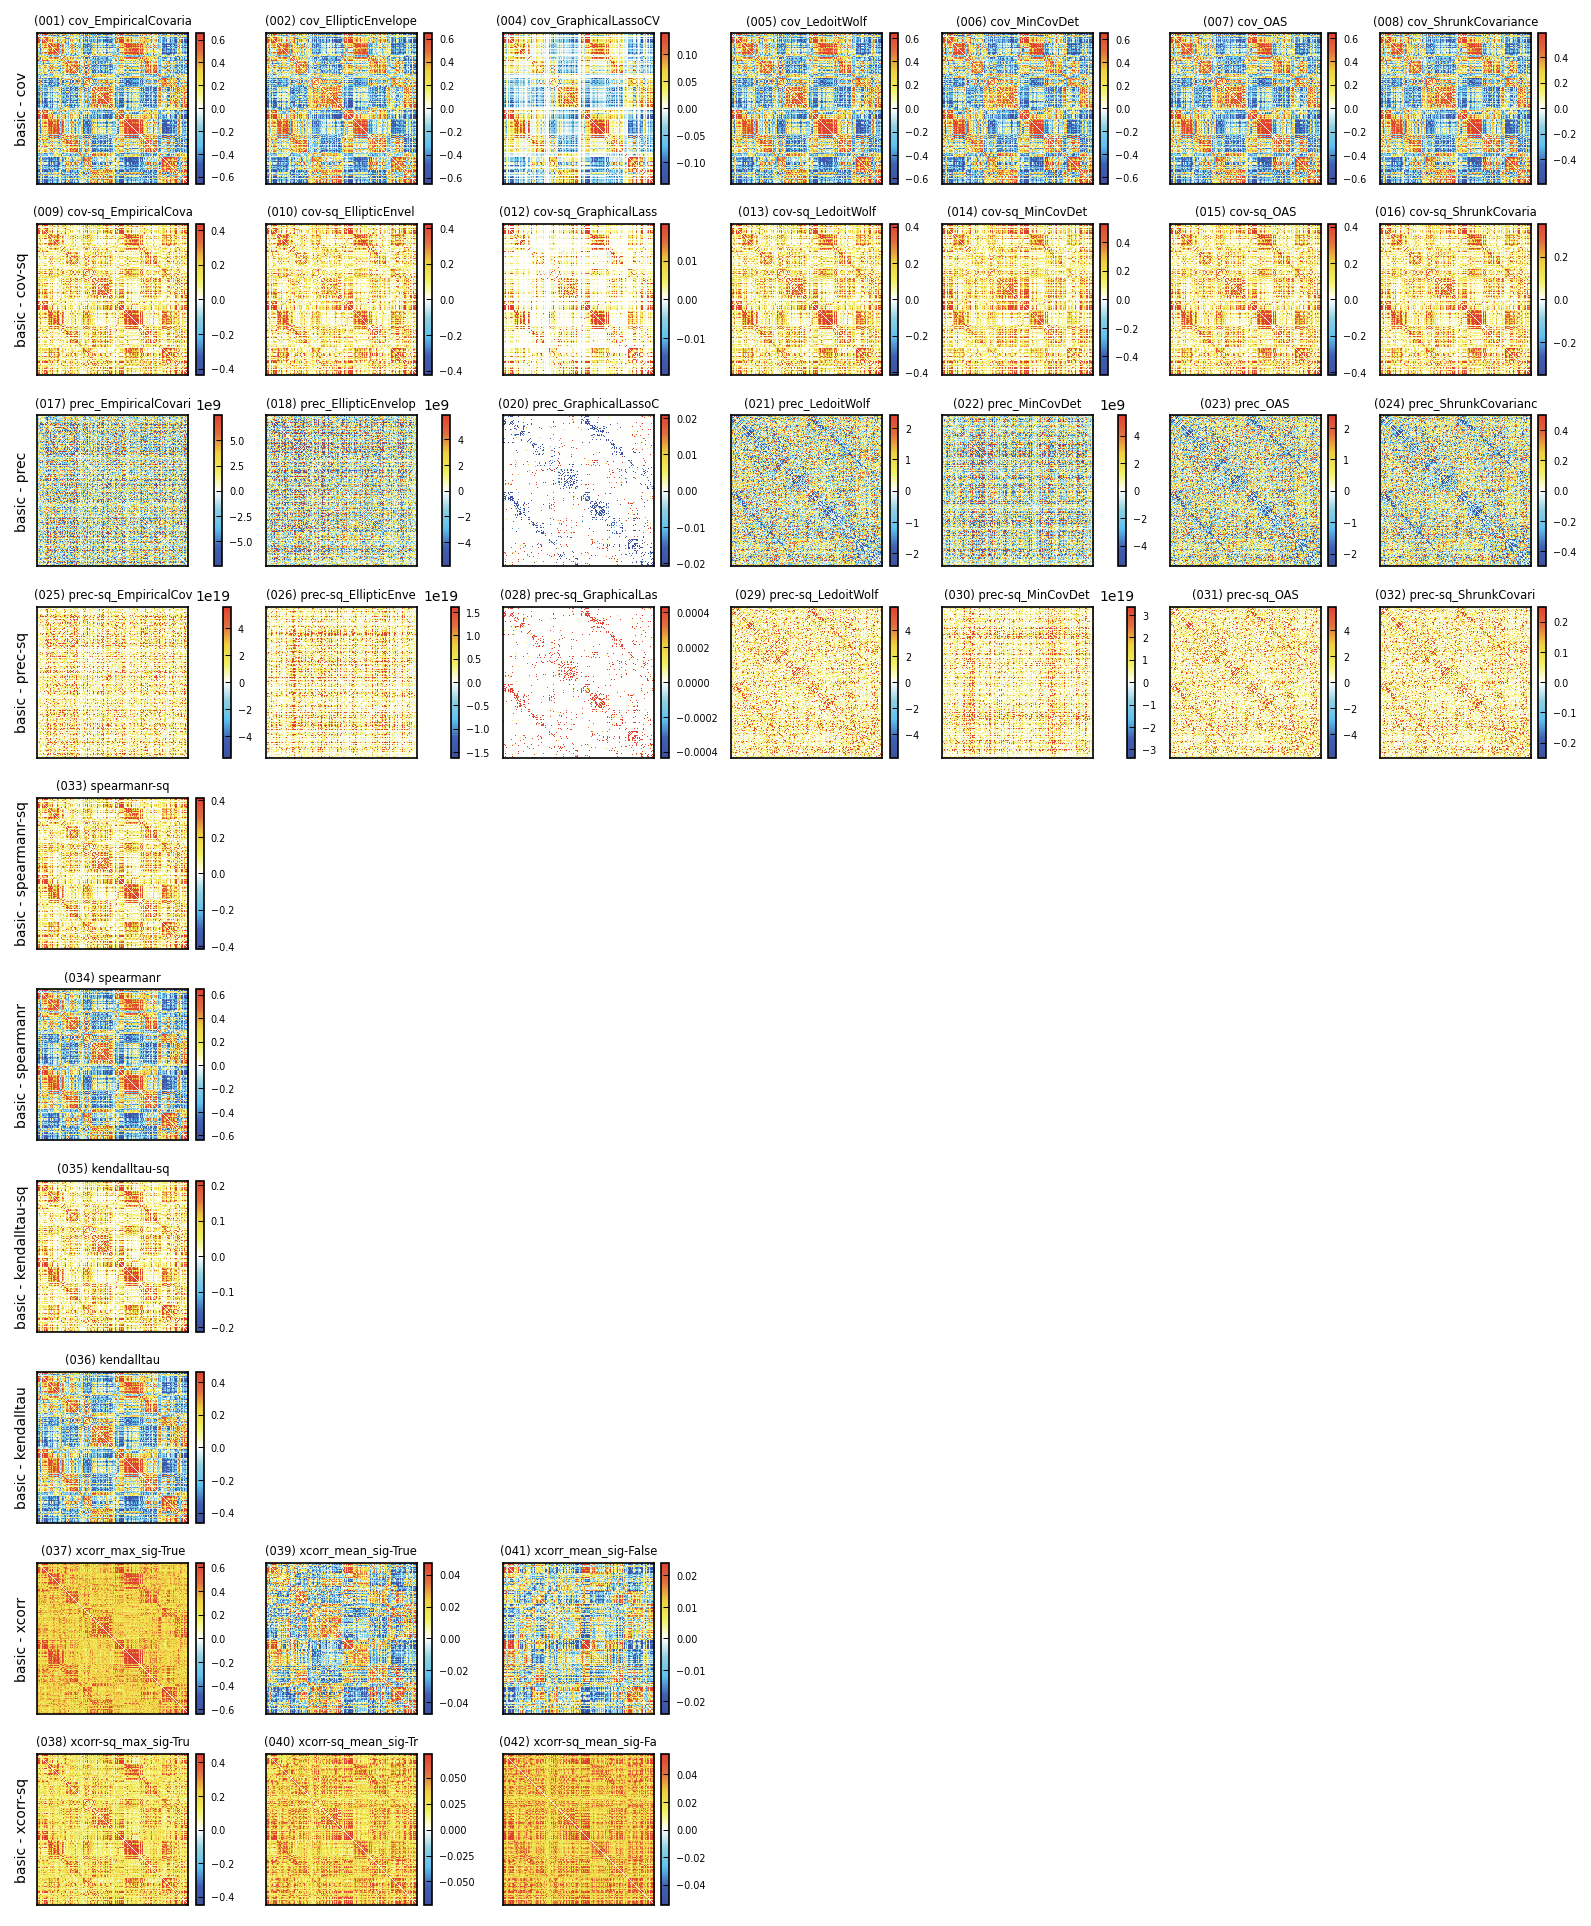

In [36]:
f = plot_example_matrices_by_func("basic")
f.show()

In [37]:
f = plot_example_matrices_by_func()
f.savefig(
    analyze_test_profile_dir / "example_spi_matrices_by_func.png",
    bbox_inches="tight",
)
plt.close(f)

In [38]:
def plot_example_matrices_flat(category: str | None = None):
    if category is not None:
        cat_mat_df = mat_df.query(f"category == '{category}'")
    else:
        cat_mat_df = mat_df

    plotw = 1.5
    ploth = 0.85 * plotw

    ncol = 12
    nrow = int(np.ceil(len(cat_mat_df) / ncol))

    f, axs = plt.subplots(
        nrow, ncol, figsize=(ncol * plotw, nrow * ploth), layout="constrained"
    )
    axs = axs.flatten()

    for ii, ax in enumerate(axs):
        plt.sca(ax)
        if ii >= len(cat_mat_df):
            plt.axis("off")
            continue

        cat = mat_df.loc[ii, "category"]
        spi = mat_df.loc[ii, "spi"]

        mat = mat_df.loc[ii, "mat"]
        mat = mat.reshape(base_n_features, base_n_features)

        vmax = max(np.nanquantile(np.abs(mat), 0.95), 1e-8)
        matshow(mat, vmax=vmax)
        cbar = plt.colorbar(fraction=0.05, pad=0.05)
        cbar.ax.tick_params(labelsize="xx-small")

        title = f"({cat[0].upper()}) ({spi_id_map[spi] + 1:03d}) {spi}"
        plt.title(title[:26], fontsize="x-small", pad=4)

    return f

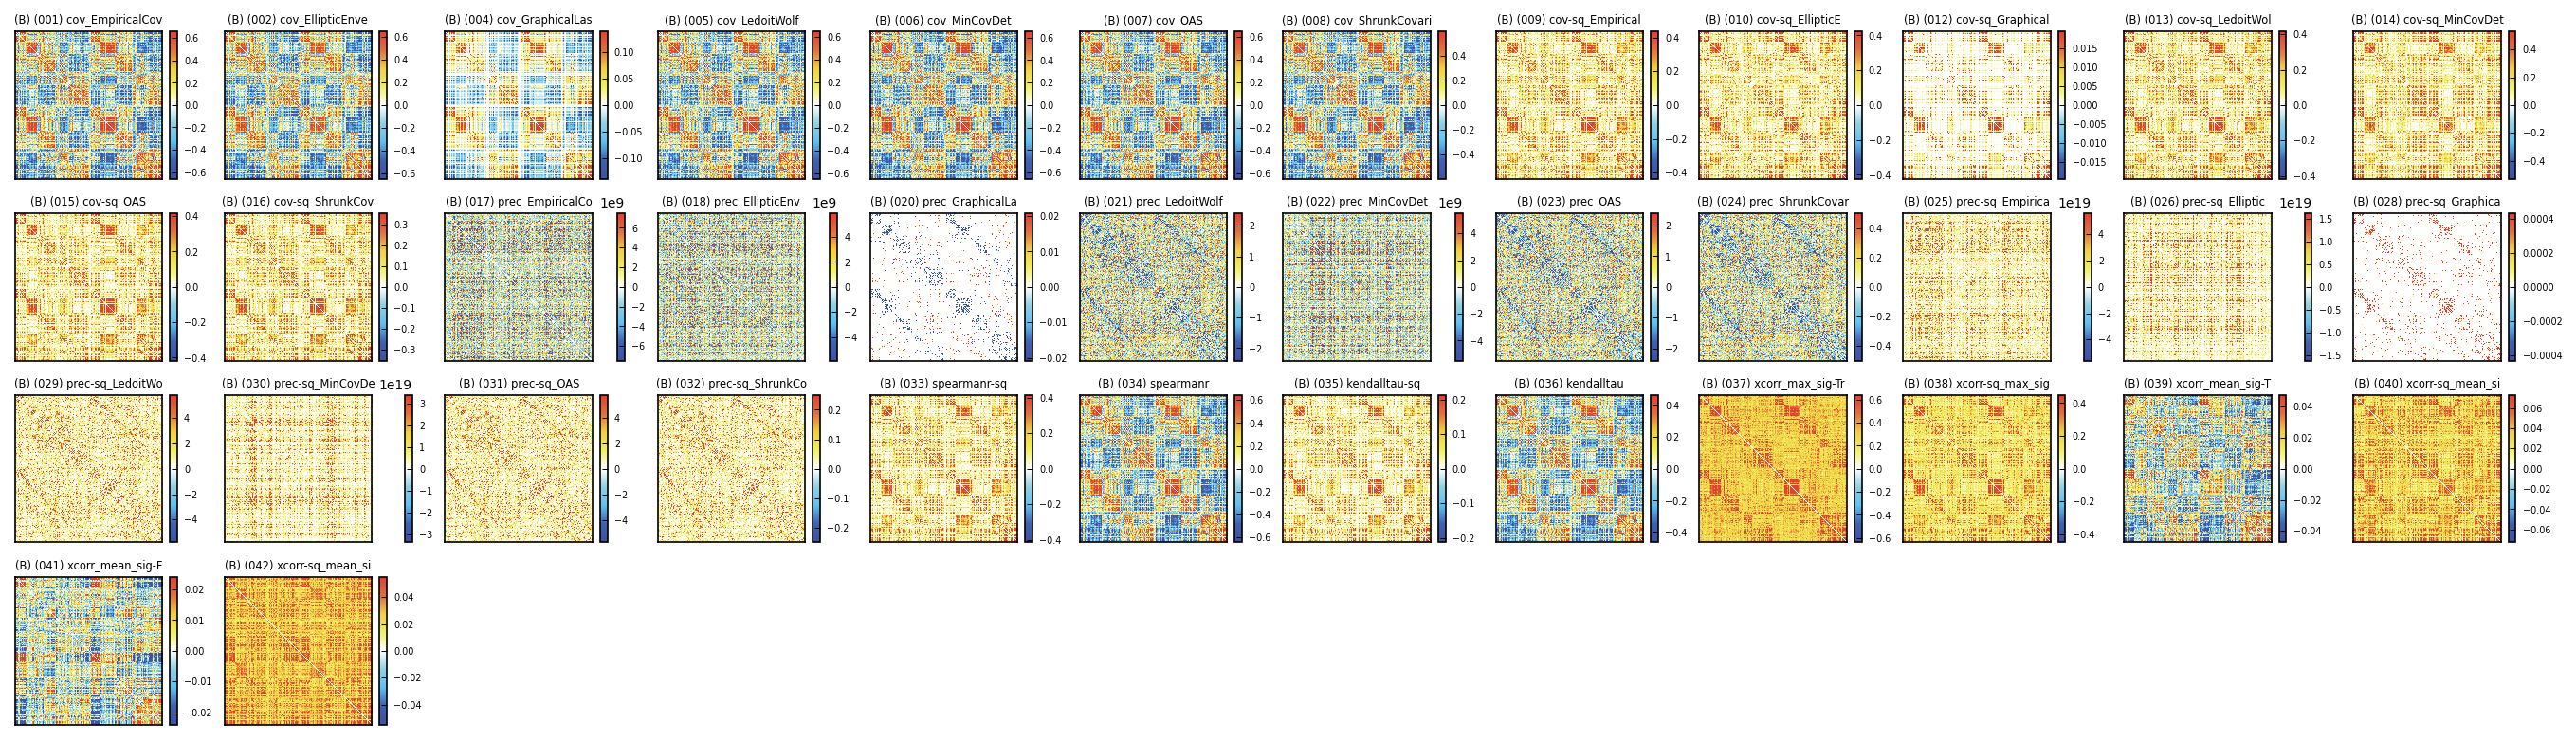

In [39]:
f = plot_example_matrices_flat("basic")
f.show()

In [40]:
f = plot_example_matrices_flat()
f.savefig(
    analyze_test_profile_dir / "example_spi_matrices_flat.png",
    bbox_inches="tight",
)
plt.close(f)